<a href="https://colab.research.google.com/github/amina-mardiyyah/Data_Science_For_Life_Scientist_Course/blob/main/session1A_dnn_pubmed_rct20k_tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Session 1 Tutorial Notebook: Introduction to DNNs and Transformers

**Course:** Data Science for Life Scientists  
**Practical focus:** Sentence Classification with the PubMed RCT 20k dataset

This particular notebook will only focus on training a small DNN classifier. In part B, we'll explore a similar task by finetuning a transformer.

By the end of this notebook, you will:
- load and inspect a biomedical text classification dataset
- train a simple feed-forward neural network (MLP) on text features
- save predictions and metrics for Session 2, where we will focus on evaluation and visualisation

## Dataset description?

We will use the **PubMed RCT 20k** dataset from Hugging Face. This dataset is a sentence-level biomedical abstract classification task with five labels: **background, objective, methods, results,** and **conclusions**.

For this task, we'll use a subset of the dataset

In [1]:
#Dependency imports

#Standard Library
import os
import json
import re
import random
from pathlib import Path
import joblib

# Ignore unnecessary library warnings
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=SyntaxWarning)


#Data manipulation and Visualisation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


#scikit-learn
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.utils import shuffle as sk_shuffle


#pytorch, transformers and HF datasets
from datasets import load_dataset, DatasetDict, Dataset
import torch



In [2]:
#constants

# Reproducibility
SEED = 42  # other seeds to try: 3407, 2026, 123
SUBSET_SIZE = 8000

# Output folders for Session 1A artifacts
OUTPUT_DIR = Path('artifacts/session1A_dnn')
DATA_DIR = OUTPUT_DIR / 'data'
PRED_DIR = OUTPUT_DIR / 'predictions'
MODEL_DIR = OUTPUT_DIR / 'model_weights'
for path in [OUTPUT_DIR, DATA_DIR, PRED_DIR, MODEL_DIR]:
    path.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")


Using device: cpu


In [3]:
#set and init reproducibility
def set_global_seed(seed):
    "Ensures reproducibility across multiple libraries"
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_global_seed(SEED)

## Step 1 — Load the dataset

Run the next cell to download the PubMed RCT 20k dataset from Hugging Face and inspect the available splits.

In [4]:
#load and inspect dataset from huggingface
dataset = load_dataset("armanc/pubmed-rct20k")
print(dataset)

Repo card metadata block was not found. Setting CardData to empty.


DatasetDict({
    train: Dataset({
        features: ['abstract_id', 'label', 'text', 'sentence_id'],
        num_rows: 176642
    })
    validation: Dataset({
        features: ['abstract_id', 'label', 'text', 'sentence_id'],
        num_rows: 29672
    })
    test: Dataset({
        features: ['abstract_id', 'label', 'text', 'sentence_id'],
        num_rows: 29578
    })
})


For this tutorial, we'll only be using a subset of the dataset. We'll do this by generating a small sample from the training split which we'll further split into train, validation and test in upcoming cells.

The next cell shuffles the default dataset training split and keeps the first `SUBSET_SIZE` examples before we create our own train/validation/test split.


In [5]:
# Create a smaller working subset from the training split
sampled_dataset = dataset['train'].select(range(SUBSET_SIZE))
print(sampled_dataset)

Dataset({
    features: ['abstract_id', 'label', 'text', 'sentence_id'],
    num_rows: 8000
})


In [6]:
# Split the sampled data into train / validation / test using 60:20:20
# First split: 70% train, 30% temporary holdout
train_test_split_dataset = sampled_dataset.train_test_split(test_size=0.40, seed=SEED)
train_dataset = train_test_split_dataset['train']
temp_test_val_dataset = train_test_split_dataset['test']

# Second split: 20% validation, 20% test
test_val_split_dataset = temp_test_val_dataset.train_test_split(test_size=0.50, seed=SEED)
validation_dataset = test_val_split_dataset['train']
test_dataset = test_val_split_dataset['test']

# Reconstruct the dataset dictionary
dataset = DatasetDict({
    'train': train_dataset,
    'validation': validation_dataset,
    'test': test_dataset,
})

print(
    f"Dataset sizes after 60:20:20 split:\n"
    f"Train: {len(dataset['train'])}\n"
    f"Validation: {len(dataset['validation'])}\n"
    f"Test: {len(dataset['test'])}"
)


Dataset sizes after 60:20:20 split:
Train: 4800
Validation: 1600
Test: 1600


In [7]:
#inspect dataset labels
observed_labels = dataset['train'].unique('label')
print("Total number of labels in dataset: ", len(observed_labels))
print("Label names:", observed_labels)

Total number of labels in dataset:  5
Label names: ['background', 'methods', 'results', 'objective', 'conclusions']


In [8]:
#keep a fixed order for reproducibility
LABEL_LIST = ['background', 'methods', 'results', 'objective', 'conclusions']

## Step 2 — Inspect dataset and Label distribution

A useful step before model training is to explore the dataset by reviewing a few examples and analysing the label distribution. This helps build intuition about the task and reveals whether the classes are balanced or imbalanced.

In [9]:
# Convert the train split to a DataFrame for quick inspection
train_df = dataset['train'].to_pandas()
train_df.head(10)

,abstract_id,label,text,sentence_id
0,25258143,background,Eosinophilic esophagitis ( EoE ) is a chronic ...,0
1,25675682,methods,The anesthesia breathing circuit was switched ...,7
2,25216649,background,Most studies use a tonic voluntary contraction...,1
3,24666029,results,"Within the variability , we found that @-methy...",4
4,25165090,methods,Regressions controlled for alarm status preint...,7
5,24976083,results,"There were @ tertiary ( n = @,@ patients ) and...",3
6,24231555,results,Substantial improvements in RSA best time ( RS...,6
7,24308191,methods,Manual acupuncture stimulation was applied to ...,3
8,25948400,methods,"Bodyweight , milk production , and somatic cel...",4
9,25036199,results,"The authors enrolled @ patients , of whom @ we...",8


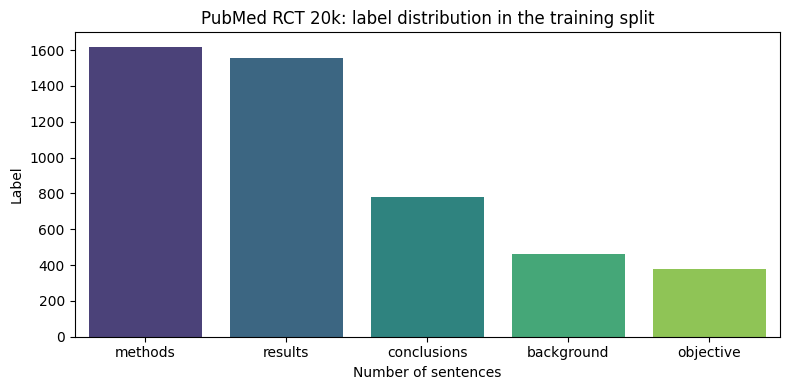

In [10]:
# Plot label distribution on the training split
label_counts = train_df["label"].value_counts().sort_values(ascending=False)

#plot label distribution using seaborn
plt.figure(figsize=(8, 4))
sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis',
            hue=label_counts.index, legend=False)
plt.title("PubMed RCT 20k: label distribution in the training split")
plt.xlabel("Number of sentences")
plt.ylabel("Label")
plt.tight_layout()
plt.show()

In [11]:
#temporary create a text length column to inspect length of texts
train_df["text_len"] = train_df["text"].apply(lambda x: len(x.split()))
train_df.text_len.describe()

,text_len
count,4800.000000
mean,26.153333
std,14.839315
min,2.000000
25%,16.000000
50%,23.000000
75%,32.000000
max,140.000000


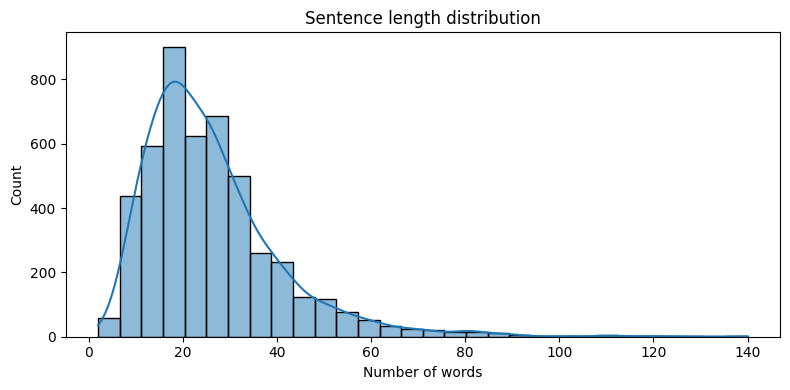

In [12]:
# Sentence length distribution
train_lengths = pd.Series([len(text.split()) for text in train_df["text"]])

# Refactored to use seaborn for plotting sentence length distribution
plt.figure(figsize=(8, 4))
sns.histplot(train_lengths, bins=30, kde=True)
plt.title("Sentence length distribution")
plt.xlabel("Number of words")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [13]:
train_df.tail()

,abstract_id,label,text,sentence_id,text_len
4795,24228528,results,"Among them , D value of four families ( @ , @ ...",4,24
4796,24238397,methods,We used a structured questionnaire to survey o...,2,13
4797,24447063,results,The intervention group had significantly fewer...,13,24
4798,25349296,conclusions,Patients should be offered re-treatment for pa...,9,25
4799,25454175,methods,NACT-RT consisted of @Gy/@/ff concurrent with ...,3,28


In [14]:
#inspect a sample sentence
train_df.text.iloc[10]

'The prespecified primary outcome was treatment failure at @ weeks after enrollment , defined as perforation and/or increase in ulcer size by @ mm .'

In [15]:
train_df.sample(20)

,abstract_id,label,text,sentence_id,text_len
596,25168032,results,Demand intensity ( consumption at low prices )...,7,19
3370,24399652,results,Lower baseline binge eating episode frequency ...,6,18
3048,25411141,methods,Each subject had three laser treatments one mo...,5,10
2908,25472864,results,"Of these patients , primary outcome data were ...",9,20
8,25948400,methods,"Bodyweight , milk production , and somatic cel...",4,23
577,24763478,methods,"The anterior surface of the cornea , epitheliu...",2,30
2867,24354588,conclusions,Strengths of this study further include collec...,10,32
811,25302624,results,Groups had similar baseline characteristics ( ...,5,10
3509,25176152,results,Secondary outcomes ( failure and pain ) did no...,11,37
1538,24758073,methods,"Meanwhile , any adverse event was recorded and...",8,10


We can see that some of the text contains weird characters and equation symbols like `@` `=` .

Could this mean anything?
For now,  we can clean these out from the text.

In [16]:
import re
def clean_text(text:str) -> str:
    """
    This function cleans a text by filtering reference patterns in text,
    extra whitespaces, and special characters.

    Args:
    text(str): The text to be cleaned

    Returns:
    tex(str): The cleaned text

    """

    # Remove reference tags like [34] or [1,2,3]
    text = re.sub(r"\[\s*(\d+\s*(,\s*\d+\s*)*)\]", "", text)

    # Remove special characters like '@' and '='
    text = re.sub(r"[@=]", "", text)

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [17]:
train_df['text'] = train_df['text'].apply(clean_text)
train_df.tail()

,abstract_id,label,text,sentence_id,text_len
4795,24228528,results,"Among them , D value of four families ( , , , ...",4,24
4796,24238397,methods,We used a structured questionnaire to survey o...,2,13
4797,24447063,results,The intervention group had significantly fewer...,13,24
4798,25349296,conclusions,Patients should be offered re-treatment for pa...,9,25
4799,25454175,methods,NACT-RT consisted of Gy//ff concurrent with FU...,3,28


In [18]:
# Repeat the preprocessing steps for validation and test sets
test_df = dataset['test'].to_pandas()
test_df['text'] = test_df['text'].apply(clean_text)

val_df = dataset['validation'].to_pandas()
val_df['text'] = val_df['text'].apply(clean_text)

In [19]:
#drop text col from train_ds as it's no longer needed
train_df.drop(columns=['text_len'], inplace=True)

In [20]:
#save a copy of the cleaned dataset
train_df.to_csv(DATA_DIR / "train.csv", index=False)
test_df.to_csv(DATA_DIR / "test.csv", index=False)
val_df.to_csv(DATA_DIR / "val.csv", index=False)

In [61]:
# or optionally if you have a hugginface account,
# note that this requires you to have a user account and your token saved in your environment
train_ds = Dataset.from_pandas(train_df, preserve_index=False)
test_ds = Dataset.from_pandas(test_df, preserve_index=False)
val_ds = Dataset.from_pandas(val_df, preserve_index=False)

pubmed_ds = DatasetDict({
    "train": train_ds,
    "test": test_ds,
    "validation": val_ds
})

pubmed_ds.push_to_hub("pubmed-rct-subset_cleaned", commit_message="Add Pubmed RCT dataset")


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/5 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              : 100%|##########|  477kB /  477kB            

...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              : 100%|##########|  167kB /  167kB            

README.md:   0%|          | 0.00/4.95k [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/datasets/Mardiyyah/pubmed-rct-subset_cleaned/commit/e54303ca6e1b11a496314777f646e7a2c3350c4a', commit_message='Add Pubmed RCT dataset', commit_description='', oid='e54303ca6e1b11a496314777f646e7a2c3350c4a', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/Mardiyyah/pubmed-rct-subset_cleaned', endpoint='https://huggingface.co', repo_type='dataset', repo_id='Mardiyyah/pubmed-rct-subset_cleaned'), pr_revision=None, pr_num=None)

In [23]:
pubmed_ds

DatasetDict({
    train: Dataset({
        features: ['abstract_id', 'label', 'text', 'sentence_id'],
        num_rows: 5600
    })
    test: Dataset({
        features: ['abstract_id', 'label', 'text', 'sentence_id'],
        num_rows: 1200
    })
    validation: Dataset({
        features: ['abstract_id', 'label', 'text', 'sentence_id'],
        num_rows: 1200
    })
})

## Training a DNN Model: TF-IDF + MLP

Our first model is a simple feed-forward neural network, with 1 hidden layer.

Because neural networks need numeric inputs, we'll:
- first convert text into TF-IDF features.
- compress the sparse text representation into a single vector
with SVD.
- Then finally train a small MLP

The sklearn `Pipeline` class allows us compile all of these steps seamlessly.

In [21]:
#define input features and labels
X_train = train_df["text"]
y_train = train_df["label"]

X_val = val_df["text"]
y_val = val_df["label"]

X_test = test_df["text"]
y_test = test_df["label"]


In [22]:
#we can inspect the MLP classifier for default parameters before initialising the model training
MLPClassifier

sklearn.neural_network._multilayer_perceptron.MLPClassifier

In [23]:
# A small feed-forward network for text classification
# TF-IDF -> SVD -> StandardScaler -> MLP
mlp_model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=20000, ngram_range=(1, 2), stop_words="english")),
    ("svd", TruncatedSVD(n_components=256, random_state=SEED)),
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(128,), #number of neurons in hidden layer
        activation="relu", #activation layer
        solver="adam", #optimiser
        alpha=1e-4, #regulariser
        batch_size=64,
        learning_rate_init=1e-3,
        max_iter=12, #number of epochs
        validation_fraction=0.0,
        n_iter_no_change=3,
        random_state=SEED,
        verbose=True,
    )),
])

In [24]:
#visualise the model pipeline we just compiled
mlp_model

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=20000, ngram_range=(1, 2),
                                 stop_words='english')),
                ('svd', TruncatedSVD(n_components=256, random_state=42)),
                ('scaler', StandardScaler()),
                ('mlp',
                 MLPClassifier(batch_size=64, hidden_layer_sizes=(128,),
                               max_iter=12, n_iter_no_change=3, random_state=42,
                               validation_fraction=0.0, verbose=True))])

In [25]:
#fit training examples
print("Training a simple DNN...\n")
mlp_model.fit(X_train, y_train)

Training a simple DNN...

Iteration 1, loss = 1.35165811
Iteration 2, loss = 0.88698475
Iteration 3, loss = 0.73982070
Iteration 4, loss = 0.64813596
Iteration 5, loss = 0.57262772
Iteration 6, loss = 0.50537973
Iteration 7, loss = 0.44892861
Iteration 8, loss = 0.39691819
Iteration 9, loss = 0.35105824
Iteration 10, loss = 0.30827313
Iteration 11, loss = 0.26775864
Iteration 12, loss = 0.23456887


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (12) reached and the optimization hasn't converged yet.
  warnings.warn(


Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=20000, ngram_range=(1, 2),
                                 stop_words='english')),
                ('svd', TruncatedSVD(n_components=256, random_state=42)),
                ('scaler', StandardScaler()),
                ('mlp',
                 MLPClassifier(batch_size=64, hidden_layer_sizes=(128,),
                               max_iter=12, n_iter_no_change=3, random_state=42,
                               validation_fraction=0.0, verbose=True))])

## Step 5 — Evaluate the DNN on the validation and test splits

Run the next cell to compute basic classification metrics and plot a confusion matrix. We will keep the analysis simple here and revisit evaluation in more detail in Session 2.

In [26]:
#fit on val and test set
val_pred_dnn = mlp_model.predict(X_val)
test_pred_dnn = mlp_model.predict(X_test)

In [27]:
def get_metrics(y_true, y_pred, target_names=None, print_report=True, split_name=None):
    """Return a compact summary and optionally print the full classification report."""
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)

    metrics = {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'macro_precision': float(report['macro avg']['precision']),
        'macro_recall': float(report['macro avg']['recall']),
        'macro_f1': float(report['macro avg']['f1-score']),
        'weighted_precision': float(report['weighted avg']['precision']),
        'weighted_recall': float(report['weighted avg']['recall']),
        'weighted_f1': float(report['weighted avg']['f1-score']),
    }

    if print_report:
        if split_name is not None:
            print(f"{split_name.capitalize()} Metrics:")
        print(f"Accuracy: {metrics['accuracy']:.4f}\n")
        if target_names is not None:
            print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))
        else:
            print(classification_report(y_true, y_pred, zero_division=0))

    return metrics


In [28]:
val_metrics = get_metrics(y_val, val_pred_dnn, target_names=LABEL_LIST, split_name="Validation")
val_metrics

Validation Metrics:
Accuracy: 0.6069

              precision    recall  f1-score   support

  background       0.40      0.33      0.36       196
     methods       0.40      0.43      0.42       249
     results       0.72      0.76      0.74       524
   objective       0.36      0.31      0.33       137
 conclusions       0.72      0.72      0.72       494

    accuracy                           0.61      1600
   macro avg       0.52      0.51      0.51      1600
weighted avg       0.60      0.61      0.60      1600



{'accuracy': 0.606875,
 'macro_precision': 0.5192987540614382,
 'macro_recall': 0.5105963266048641,
 'macro_f1': 0.5135412672364312,
 'weighted_precision': 0.5990299213011419,
 'weighted_recall': 0.606875,
 'weighted_f1': 0.602003713453141}

In [29]:

test_metrics = get_metrics(y_test, test_pred_dnn, target_names=LABEL_LIST, split_name="test")
test_metrics

Test Metrics:
Accuracy: 0.6250

              precision    recall  f1-score   support

  background       0.44      0.33      0.38       177
     methods       0.40      0.46      0.43       236
     results       0.72      0.78      0.75       543
   objective       0.35      0.33      0.34       122
 conclusions       0.75      0.71      0.73       522

    accuracy                           0.62      1600
   macro avg       0.53      0.52      0.52      1600
weighted avg       0.62      0.62      0.62      1600



{'accuracy': 0.625,
 'macro_precision': 0.5323399533171042,
 'macro_recall': 0.5210469320912325,
 'macro_f1': 0.5240949402272358,
 'weighted_precision': 0.623441036430252,
 'weighted_recall': 0.625,
 'weighted_f1': 0.6222703324944959}

What are a few things we could try to improve the results of the MLP?
- Increase hidden layers?
- change learning rate?
- increase iterations?
- change optimiser?
- reduce/increase regularisation?
- increase dataset size?

In [35]:
# we can try to train for longer
mlp_model2 = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=20000, ngram_range=(1, 2), stop_words="english")),
    ("svd", TruncatedSVD(n_components=256, random_state=SEED)),
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(128,), #1 hidden layer with 128 neurons each
        activation="relu", #activation layer
        solver="adam", #optimiser
        alpha=1e-3, #regulariser
        batch_size=64,
        learning_rate_init=1e-3,
        max_iter=20, #number of epochs
        validation_fraction=0.0,
        n_iter_no_change=3,
        random_state=SEED,
        verbose=True,
    )),
])


#fit and train
mlp_model2.fit(X_train, y_train)

#fit on val and test set
val_pred_dnn = mlp_model2.predict(X_val)
test_pred_dnn = mlp_model2.predict(X_test)


#print metrics
print("Validation metrics:")
get_metrics(y_val, val_pred_dnn, target_names=LABEL_LIST, split_name="validation")

print("\nTest metrics:")
get_metrics(y_test, test_pred_dnn, target_names=LABEL_LIST, split_name="test")

There are a few notable things to observe here. We'll discuss these in details in session 2

## Save the DNN predictions for Session 2

These saved files will be useful later when we focus on evaluation and visualisation.

In [30]:

# Save the fitted DNN pipeline
joblib.dump(mlp_model, MODEL_DIR / "pubmed_rct20k_mlp_classifier.joblib")


# Save validation predictions for later analysis
val_pred_df = pd.DataFrame({
    'text': X_val,
    'true_label': y_val,
    'pred_label': val_pred_dnn,
})
val_pred_df['correct'] = val_pred_df['true_label'] == val_pred_df['pred_label']
val_pred_df.to_csv(PRED_DIR / 'dnn_validation_predictions.csv', index=False)

# Save test predictions for later analysis
test_pred_df = pd.DataFrame({
    'text': X_test,
    'true_label': y_test,
    'pred_label': test_pred_dnn,
})
test_pred_df['correct'] = test_pred_df['true_label'] == test_pred_df['pred_label']
test_pred_df.to_csv(PRED_DIR / 'dnn_test_predictions.csv', index=False)

# Save summary metrics and metadata for Session 2
summary = {
    'labels': LABEL_LIST,
    'validation': val_metrics,
    'test': test_metrics,
    'dataset_name': 'pubmed-rct20k',
    'model_type': 'TF-IDF + MLP',
    'seed': SEED,
}
with open(OUTPUT_DIR / 'dnn_metrics_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)



In [31]:
#optionally push to huggingface.
#requires you to have HF account and token saved in your environment
import getpass
from huggingface_hub import HfApi
from huggingface_hub import upload_file

HF_USERNAME = getpass.getpass("Enter your_hf_username: ").capitalize()

api = HfApi()

api.create_repo(
    repo_id=f"ds-life-scientist-course-mlp-model",
    repo_type="model",
    exist_ok=True
)



upload_file(
    path_or_fileobj=f"{MODEL_DIR}/pubmed_rct20k_mlp_classifier.joblib",
    path_in_repo="pubmed_rct20k_mlp_classifier.joblib",
    repo_id=f"{HF_USERNAME}/ds-life-scientist-course-mlp-model",
    repo_type="model"
)

Enter your_hf_username: ··········


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...20k_mlp_classifier.joblib: 100%|#########9| 42.8MB / 42.9MB            

CommitInfo(commit_url='https://huggingface.co/Mardiyyah/ds-life-scientist-course-mlp-model/commit/859ee9b3bf97096e2b6577e2b2e363de107e593d', commit_message='Upload pubmed_rct20k_mlp_classifier.joblib with huggingface_hub', commit_description='', oid='859ee9b3bf97096e2b6577e2b2e363de107e593d', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Mardiyyah/ds-life-scientist-course-mlp-model', endpoint='https://huggingface.co', repo_type='model', repo_id='Mardiyyah/ds-life-scientist-course-mlp-model'), pr_revision=None, pr_num=None)

## Noticed a few things??

- are overrepresented labels performing better than underrepresented?
- is the opposite the case??
- Why do you think this is?
- is it label topology? ambiguity? difficulty level? context? class imbalance?
- what else did you notice?
- where do you think the model is confusing classes?
